In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.dpi'] = 200

# matplotlib가 가끔 그래프를 못 그릴때 필요함
%matplotlib inline 

In [45]:
# 데이터 불러오기

df = pd.read_csv('data/flight.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [46]:
df.head(3)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [47]:
# 결측치 있는지 확인하기
print(df.isna().sum())
print()
print(f'전체데이터 결측치 개수: {df.isna().sum().sum()}')

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

전체데이터 결측치 개수: 0


In [48]:
# 필요없는 컬럼 삭제하기
df = df.drop('Unnamed: 0', axis=1)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [49]:
df.describe(include='all')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,300153,300153,300153,300153,300153,300153,300153,300153,300153.000000,300153.000000,300153.000000
unique,6,1561,6,6,3,6,6,2,NaN,NaN,NaN
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy,NaN,NaN,NaN
freq,127859,3235,61343,71146,250863,91538,59097,206666,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.221021,26.004751,20889.660523
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.191997,13.561004,22697.767366
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.830000,1.000000,1105.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.830000,15.000000,4783.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.250000,26.000000,7425.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.170000,38.000000,42521.000000


In [50]:
# 타입이 object인 컬럼만 추리기
cols = df.select_dtypes('object').columns
# 각 컬럼들의 유니크한 값들의 개수를 확인
df[cols].nunique().sort_values(ascending=True)

# 아래를 확인하면 flight가 너무 크고 필요 없다는 것을 알 수 있음
# 이와 같이 필요없는 컬럼들을 제거해줄 수 있음

class                  2
stops                  3
airline                6
source_city            6
arrival_time           6
departure_time         6
destination_city       6
flight              1561
dtype: int64

In [51]:
df = df.drop(columns=['flight'])
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [52]:
# One-hot encoding 하기

df_copy = pd.get_dummies(df, drop_first=True, dtype=int)
df_copy.head(3)

,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,2.17,1,5953,0,0,0,1,0,0,1,...,0,0,0,1,0,0,0,0,1,1
1,2.33,1,5953,0,0,0,1,0,0,1,...,0,0,1,0,0,0,0,0,1,1
2,2.17,1,5956,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1


In [53]:
from sklearn.model_selection import train_test_split

# 타겟 데이터 분리
X = df_copy.drop(columns='price')
y = df_copy['price']

print(X.shape)
print(y.shape)

(300153, 30)
(300153,)


In [54]:
# 훈련 데이터와 검증 데이터를 분리 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')

X_train: (240122, 30), X_test: (60031, 30)
y_train: (240122,), y_test: (60031,)


In [55]:
from sklearn.linear_model import LinearRegression

# 선형회귀 객체 생성
lr = LinearRegression()

# 학습데이터를 제공해 학습을 시키고 모델을 생성
model = lr.fit(X_train, y_train)
s_coef = pd.Series(model.coef_, index=X.columns)
s_coef = s_coef.sort_values(key=abs, ascending=False)

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# 훈련하지 않을 데이터를 주입하여 예측결과를 얻는다.
y_pred = model.predict(X_test)

print(f'MAE :{mean_absolute_error(y_test, y_pred):.3f}')
print(f'MSE :{mean_squared_error(y_test, y_pred):.3f}')
print(f'RMSE :{root_mean_squared_error(y_test, y_pred):.3f}')
print(f'R2_score :{r2_score(y_test, y_pred):.3f}')

MAE :4553.288
MSE :45720769.756
RMSE :6761.714
R2_score :0.911


In [57]:
mae = mean_absolute_error(y_test, y_pred)
price = df['price'].mean()

print(mae / price)  # 오차율

0.21796849267798774


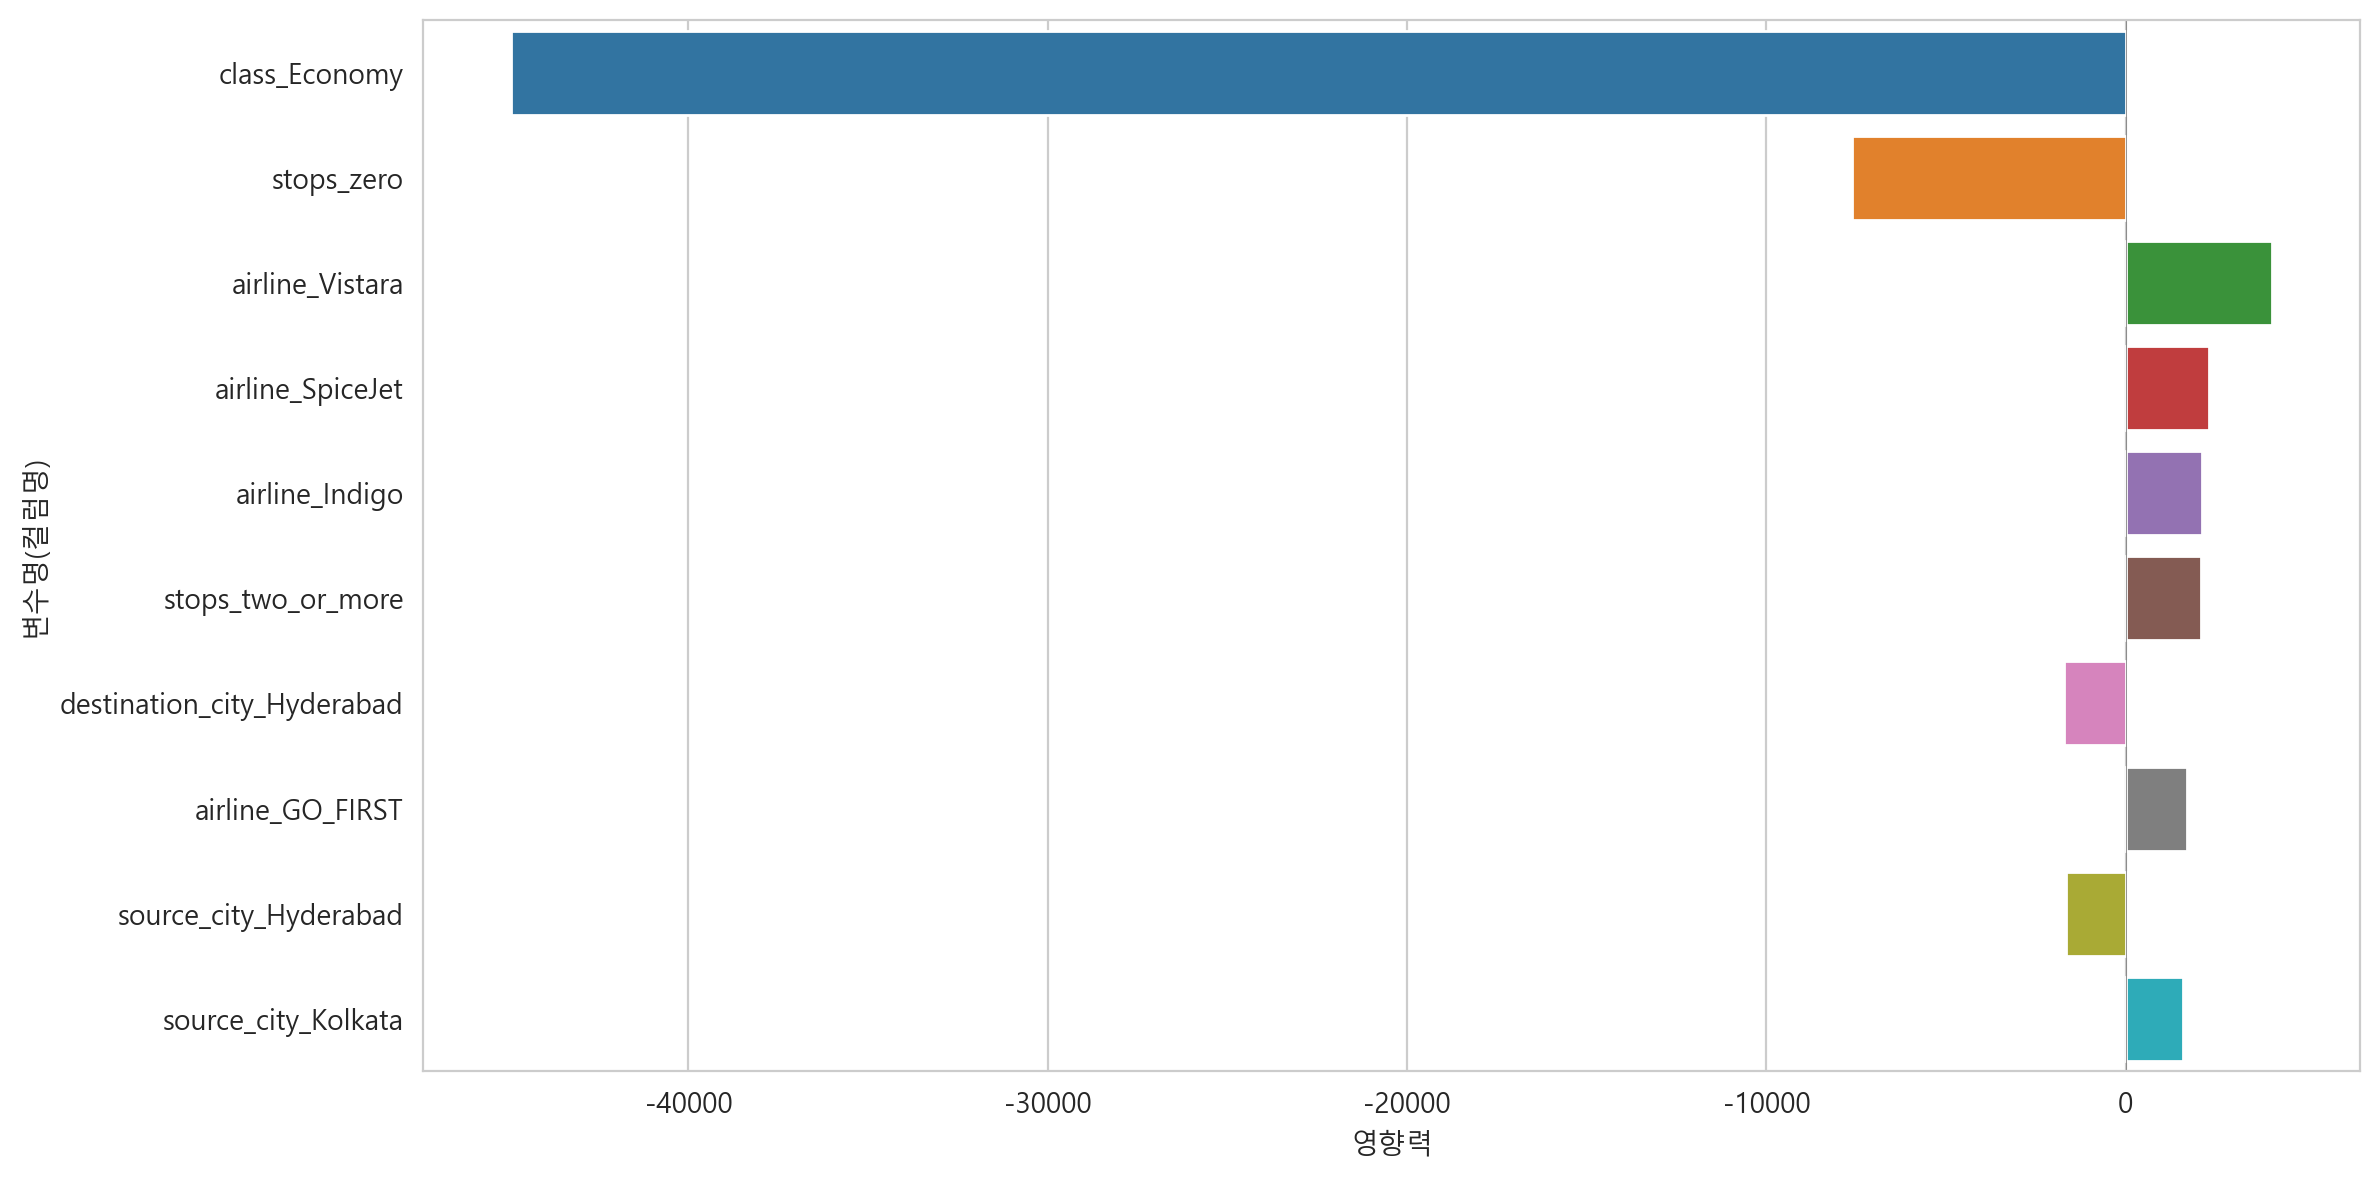

In [61]:
s_coef_top10 = s_coef.head(10)

plt.figure(figsize=(12, 6))
# Seaborn
sns.barplot(x=s_coef_top10.values, y=s_coef_top10.index, hue =s_coef_top10.index, legend = False ) # y축의 값이 legend와 같음

plt.axvline(0, color='gray', linewidth=0.3)
plt.xlabel('영향력')
plt.ylabel('변수명(컬럼명)')
plt.tight_layout()
plt.show()